# **Reconstruct the SM masking values via SM2ST**

In [ ]:
import scanpy as sc
import anndata
import pandas as pd
# import STMGraph_pyG0 as STMGraph
# import SMGraph_pyG as STMGraph
# import SM2ST_Tweedie as SM2ST
import SM2ST_wmse as SM2ST
# import SMLED
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.stats import pearsonr
os.environ['R_HOME'] = '/home/llx/software/minicbonda3/envs/pyg1/lib/R'

## **1 Read MSI**

In [2]:
df_ms=pd.read_csv('/home/llx/project/MSI_data/2025_2_21_mouse_brain/30um/ITO-PET-glass-30um_norm.csv',index_col=0)
df_ms

,x163_y1,x164_y1,x165_y1,x166_y1,x167_y1,x168_y1,x169_y1,x170_y1,x171_y1,x172_y1,...,x71_y170,x63_y171,x64_y171,x65_y171,x66_y171,x67_y171,x68_y171,x69_y171,x70_y171,x71_y171
152.021359,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
152.056053,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,334.673097,...,0.000000,110.767004,182.607266,249.665533,244.559977,197.091889,213.577722,0.000000,0.00000,0.000000
154.024872,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,151.295990,191.294577,0.000000,219.571437,133.958821,119.555462,0.000000,0.00000,169.058085
155.033100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,348.037274,...,497.200251,645.162779,732.514020,578.802570,808.645552,473.498011,556.023016,367.690765,486.14473,535.842891
156.040253,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,138.091976,0.000000,0.000000,0.000000,0.000000,100.330463,0.000000,0.00000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002.579091,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
1003.583304,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
1006.496537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
1020.535948,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000


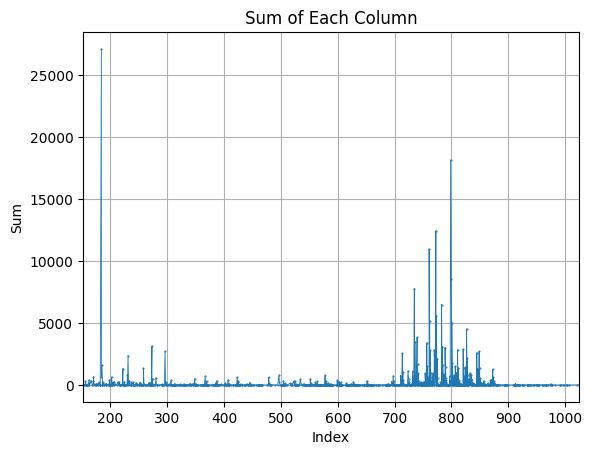

In [3]:
column_sums_i1 = df_ms.sum(axis = 1)/len(df_ms.columns)
column_sums_i1.index = column_sums_i1.index.astype(float)
# Draw a line chart
column_sums_i1.plot(kind='line', marker='.',linewidth=0.6, markersize=1)
plt.title('Sum of Each Column')
plt.xlabel('Index')
plt.ylabel('Sum')
plt.xticks(range(100, 1500, 100))  # Set the horizontal axis scale, with one mark displayed for every 100 units
plt.xlim(column_sums_i1.index.min(), column_sums_i1.index.max())  # Set the range of the horizontal axis
plt.grid(True)
plt.show()

## **2 MSI constructs anndata**

In [4]:
def create_anndata_or(dataframe=None,pixel_size=1,mask_radio=0.5):
    
    df_ms_new=dataframe.iloc[:,:].T#4
    # Filter 0
    rows_all_zero = (df_ms_new == 0).all(axis=1)

    df_ms_new = df_ms_new[~rows_all_zero]
    df_ms_new = df_ms_new.apply(lambda x: x - x.min(), axis=0)
    # Collect all the coordinates and add them to the list
    rows = []
    cols = []
    for name in df_ms_new.index:
        x, y = name.split('_y')
        rows.append(int(x[1:]))
        cols.append(int(y))

    coordinates_df = pd.DataFrame({'array_row': rows, 'array_col': cols})
    coordinates_df.index = df_ms_new.index
    coordinates_physical_df = coordinates_df*pixel_size
    # Initialize the AnnData object
    index_df = pd.DataFrame(index=dataframe.index)
    adata = anndata.AnnData(X=df_ms_new.values, obs=coordinates_df, var=index_df)#4
    adata.obsm['spatial'] = coordinates_physical_df.values
    return adata

In [5]:
adata = create_anndata_or(dataframe=df_ms,pixel_size=30)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


/tmp/ipykernel_838174/1356522396.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data_nonzero, shade=True)


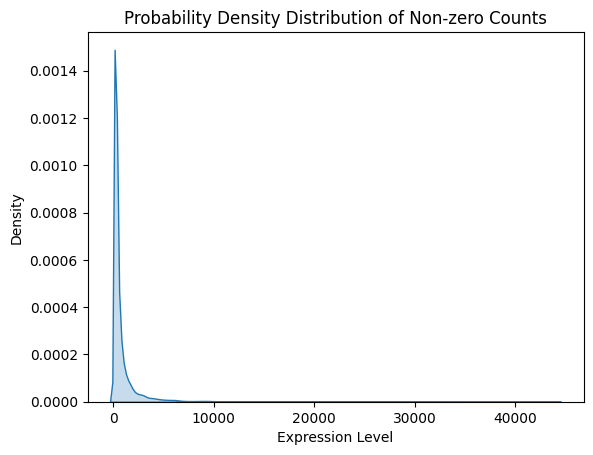

In [6]:
import scipy
import seaborn as sns

# If adata.X is not a sparse matrix, convert it to a dense matrix (as needed)
if scipy.sparse.issparse(adata.X):
    data = adata.X.A.flatten()
else:
    data = adata.X

# Filter out all the 0 values so as to better observe the distribution of non-zero values
data_nonzero = data[data != 0]

# Draw the probability density distribution graph
sns.kdeplot(data_nonzero, shade=True)

plt.title('Probability Density Distribution of Non-zero Counts')
plt.xlabel('Expression Level')
plt.ylabel('Density')

plt.show()

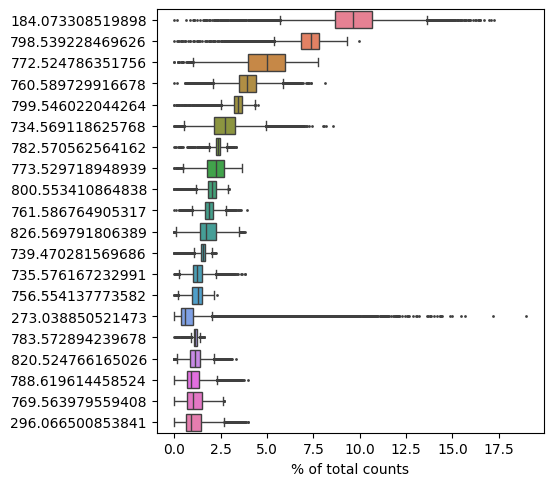

In [7]:
sc.pl.highest_expr_genes(adata, n_top=20, )

<Axes: title={'center': '159.00465933054'}, xlabel='spatial1', ylabel='spatial2'>

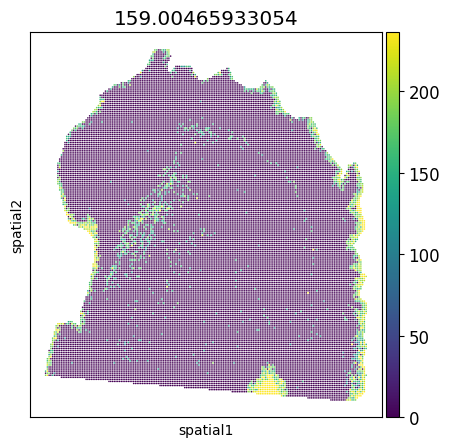

In [8]:
plot_gene = '159.00465933054'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5)) 
plt.rcParams['font.size'] = 12  
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

In [9]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

<Axes: title={'center': '152.056052536344'}, xlabel='spatial1', ylabel='spatial2'>

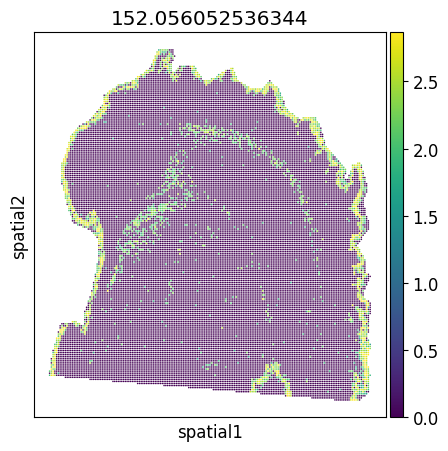

In [10]:
plot_gene = '152.056052536344' # C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))
plt.rcParams['font.size'] = 12
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

## **3 Recovery the masked points**

In [11]:
adata_sample, adata_SMLED = SM2ST.train_SMLED(adata=adata, keep_ratio=0.5, coord_sf=2.0, train_epoch=10000, experiment='recovery', WMMSE = 1)# 0.3 0.7

Size of Input:  (23626, 1273)
30.0 30.0
pixel_step: 60.0
          0     1
0      82.5   1.0
1      83.0   1.0
2      83.5   1.0
3      84.5   1.0
4      85.0   1.0
...     ...   ...
11808  32.5  86.0
11809  33.5  86.0
11810  34.0  86.0
11811  35.5  86.0
11812  36.0  86.0

[11813 rows x 2 columns]           0     1
0      82.0   1.0
1      82.5   1.0
2      83.0   1.0
3      83.5   1.0
4      84.0   1.0
...     ...   ...
23621  34.0  86.0
23622  34.5  86.0
23623  35.0  86.0
23624  35.5  86.0
23625  36.0  86.0

[23626 rows x 2 columns]


Epochs: 100% 10000/10000 [16:34:55<00:00,  5.97s/it, loss_re: 0.08975, loss_lat: 0.36472, loss_GA: 0.00003, loss: 0.19919, loss_DA: 1.38628] 


<Axes: title={'center': '152.056052536344'}, xlabel='spatial1', ylabel='spatial2'>

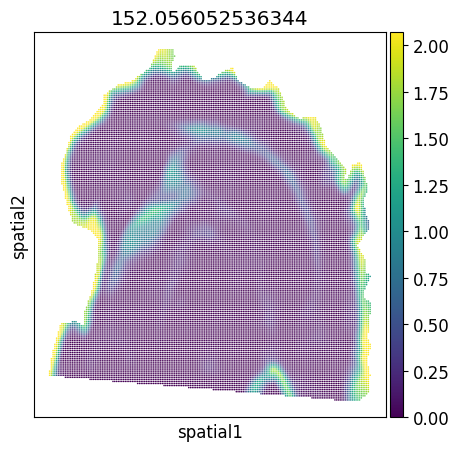

In [12]:
#new
plot_gene = '152.056052536344'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '152.056052536344'}, xlabel='spatial1', ylabel='spatial2'>

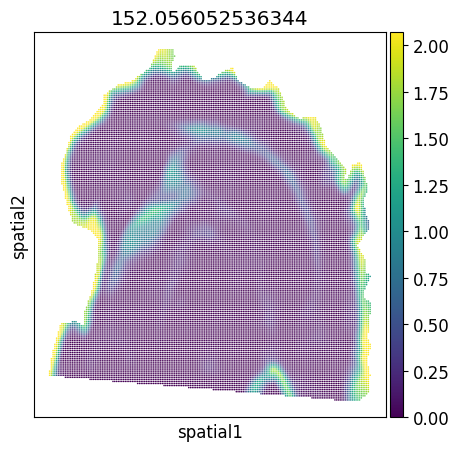

In [13]:
#new
plot_gene = '152.056052536344'#C27H35N9O15P2Na
fig, ax = plt.subplots(figsize=(5, 5))  # width = 15, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '259.11315312222'}, xlabel='spatial1', ylabel='spatial2'>

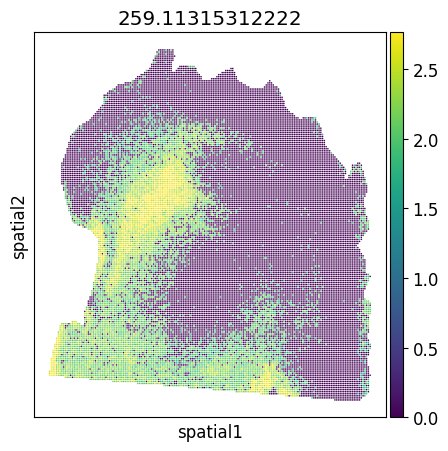

In [14]:
#new
plot_gene = '259.11315312222'
fig, ax = plt.subplots(figsize=(5, 5)) 
plt.rcParams['font.size'] = 12 
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '259.11315312222'}, xlabel='spatial1', ylabel='spatial2'>

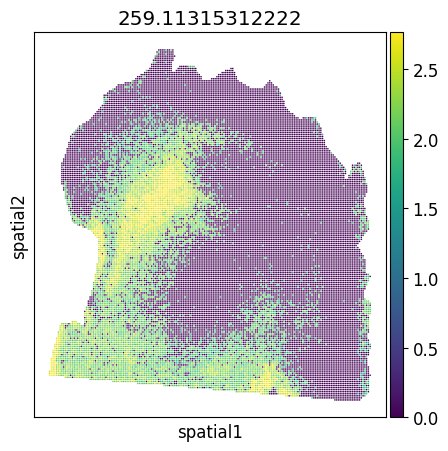

In [15]:
#new
plot_gene = '259.11315312222'
fig, ax = plt.subplots(figsize=(5, 5))  # width = 5, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '259.11315312222'}, xlabel='spatial1', ylabel='spatial2'>

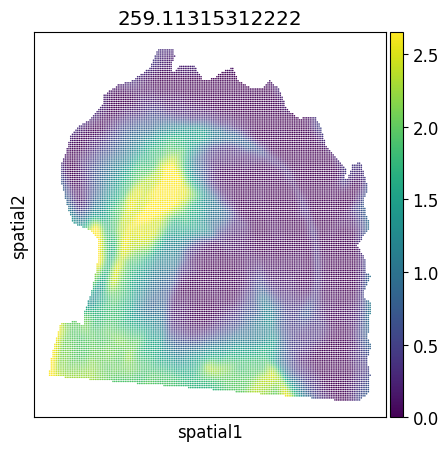

In [16]:
#new
plot_gene = '259.11315312222'
fig, ax = plt.subplots(figsize=(5, 5))  # width = 5, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '152.056052536344'}, xlabel='spatial1', ylabel='spatial2'>

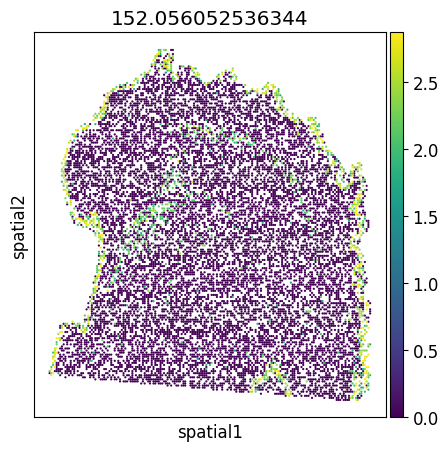

In [17]:
#new
plot_gene = '152.056052536344'
fig, ax = plt.subplots(figsize=(5, 5))  # width = 5, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata_sample, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '259.11315312222'}, xlabel='spatial1', ylabel='spatial2'>

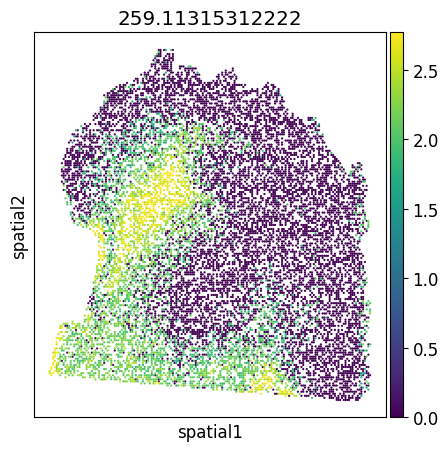

In [18]:
#new
plot_gene = '259.11315312222'
fig, ax = plt.subplots(figsize=(5, 5))  # width = 5, height = 5
plt.rcParams['font.size'] = 12  #  default font size is 10
sc.pl.embedding(adata_sample, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

<Axes: title={'center': '159.00465933054'}, xlabel='spatial1', ylabel='spatial2'>

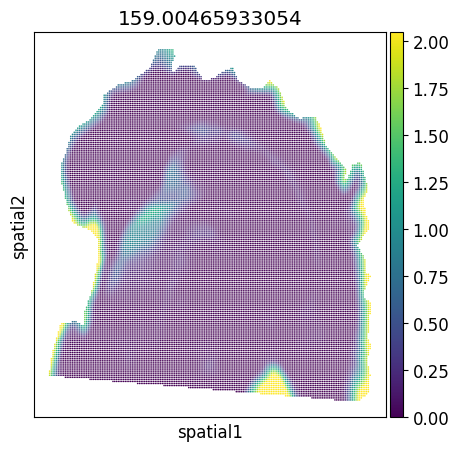

In [19]:
plot_gene = '159.00465933054'
fig, ax = plt.subplots(figsize=(5, 5)) 
plt.rcParams['font.size'] = 12 
sc.pl.embedding(adata_SMLED, basis="spatial", color=plot_gene, show=False,vmax='p99', ax=ax)

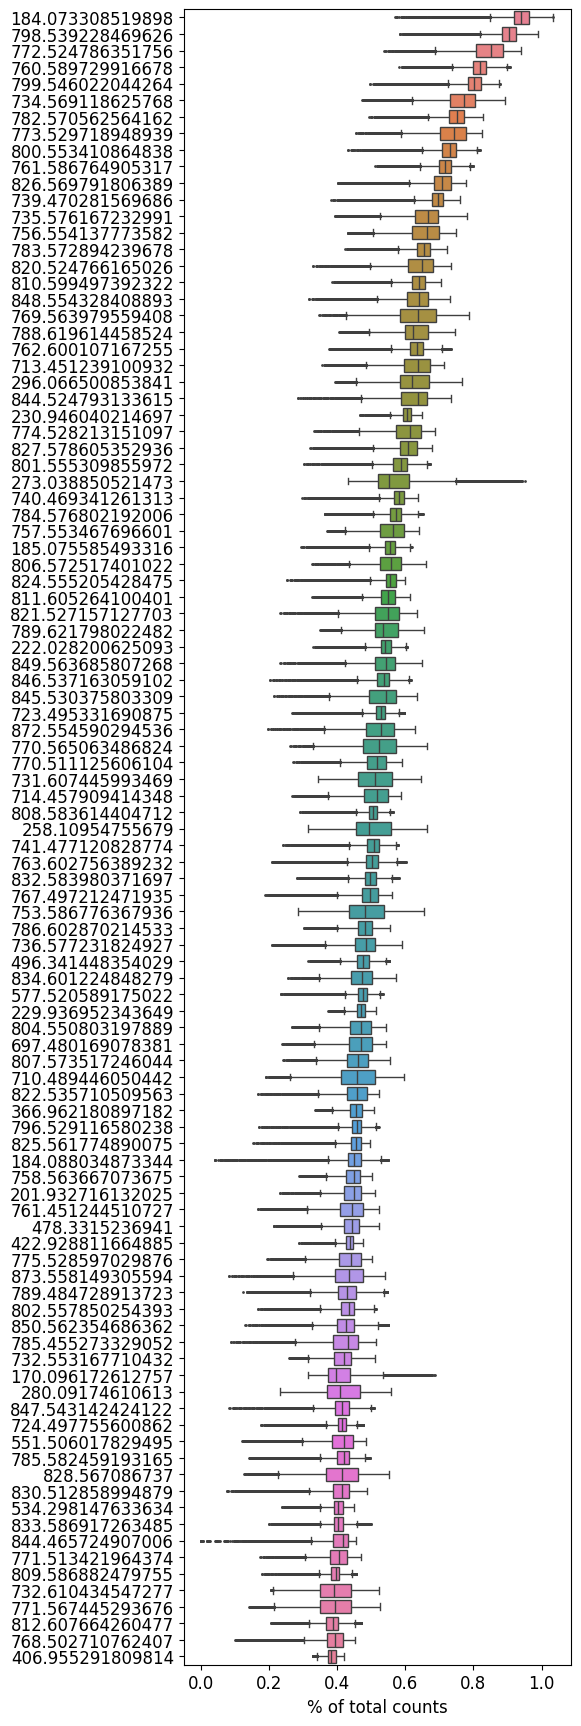

In [20]:
sc.pl.highest_expr_genes(adata_SMLED, n_top=100, )

In [22]:
adata_SMLED

AnnData object with n_obs × n_vars = 23626 × 1273
    obs: 'array_row', 'array_col'
    obsm: 'spatial'

In [23]:
# adata_SMLED.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_SMLEDo_wmse1.h5ad')
# adata_sample.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_sampleo_wmse1.h5ad')

In [25]:
# adata_SMLED.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_SMLEDo.h5ad')
# adata_sample.write_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_sampleo.h5ad')

In [36]:
adata_SMLED=sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_SMLEDo.h5ad')
adata_sample = sc.read_h5ad('/home/llx/project/jupyternotebook/1_pyg_backup/SMLED_pyG_result/ITO-PET-glass-30um_sampleo.h5ad')

## **4 Pearson correlation**

In [37]:
# Create mask: Keep the observations that are not in adata_sample
mask = ~adata_SMLED.obs_names.isin(adata_sample.obs_names)

In [38]:
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import pandas as pd

A = adata_SMLED[mask,:].X.A
B = adata[mask,:].X

r_values = []
p_values = []
for col1, col2 in zip(A, B):
    r_value, p_value = pearsonr(col1, col2)
    r_values.append(r_value)
    p_values.append(p_value)

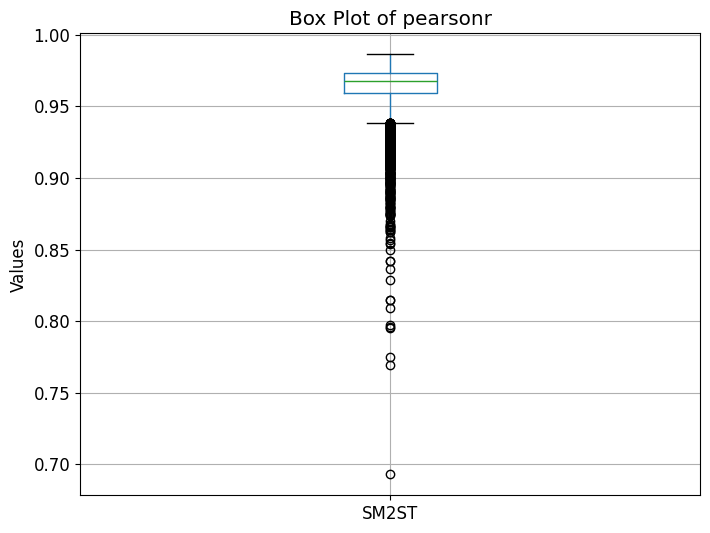

In [39]:
df = pd.DataFrame(r_values, columns=['SM2ST'])

plt.figure(figsize=(8, 6)) 
df.boxplot()

plt.title('Box Plot of pearsonr')
plt.suptitle('') 
plt.xlabel('')#Columns
plt.ylabel('Values')

plt.show()

## **5 SSIM**

In [24]:
import squidpy as sq
sq.gr.spatial_neighbors(adata_SMLED)
sq.gr.spatial_autocorr(adata_SMLED, mode="moran", genes=adata_SMLED.var_names)
sq.gr.spatial_autocorr(adata_SMLED, mode="geary", genes=adata_SMLED.var_names)

sq.gr.spatial_neighbors(adata)
sq.gr.spatial_autocorr(adata, mode="moran", genes=adata.var_names)
sq.gr.spatial_autocorr(adata, mode="geary", genes=adata.var_names)

/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 113 variables were constant, will return nan for these.
  warnings.warn(
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 113 variables were constant, will return nan for these.
  warnings.warn(
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 155 variables were constant, will return nan for these.
  warnings.warn(
/home/llx/software/miniconda3/envs/pyg_ms/lib/python3.9/site-packages/scanpy/metrics/_gearys_c.py:295: UserWarning: 155 variables were constant, will return nan for these.
  warnings.warn(


In [25]:
ms_adata_high_moran_genes = adata.uns['moranI']['I'][(adata.uns['moranI']['I'] > 0.15) & (adata.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_moran = adata[:, ms_adata_high_moran_genes]

ms_adata_high_geary_genes = adata.uns['gearyC']['C'][(adata.uns['gearyC']['C'] < 0.7) & (adata.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
ms_adata_high_geary = adata[:, ms_adata_high_geary_genes]

In [26]:
adata_SMLED_high_moran_genes = adata_SMLED.uns['moranI']['I'][(adata_SMLED.uns['moranI']['I'] > 0.15) & (adata_SMLED.uns['moranI']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_moran = adata_SMLED[:, adata_SMLED_high_moran_genes]

adata_SMLED_high_geary_genes = adata_SMLED.uns['gearyC']['C'][(adata_SMLED.uns['gearyC']['C'] < 0.7) & (adata_SMLED.uns['gearyC']['pval_norm'] < 0.05)].index.tolist()
adata_SMLED_high_geary = adata_SMLED[:, adata_SMLED_high_geary_genes]

In [27]:
ms_adata_set1 = set(ms_adata_high_geary.var_names)
ms_adata_set2 = set(ms_adata_high_moran.var_names)
ms_adata_v = ms_adata_set1&ms_adata_set2

In [28]:
adata_SMLED_set1 = set(adata_SMLED_high_geary.var_names)
adata_SMLED_set2 = set(adata_SMLED_high_moran.var_names)
adata_SMLED_v = adata_SMLED_set1&adata_SMLED_set2

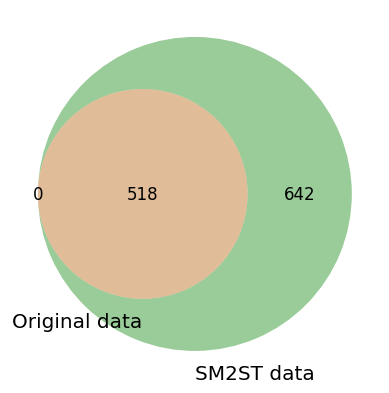

In [29]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

set1 = ms_adata_v
set2 = adata_SMLED_v

venn = venn2([set1, set2], ('Original data', 'SM2ST data'))

venn.get_label_by_id('100').set_text(f'{len(set1 - set2)}')
venn.get_label_by_id('010').set_text(f'{len(set2 - set1)}')
venn.get_label_by_id('110').set_text(f'{len(set1 & set2)}')

plt.show()

In [30]:
gene = adata_SMLED.var_names.isin(ms_adata_v)

In [44]:
import numpy as np
import anndata as ad
from skimage.metrics import structural_similarity as ssim
from scipy.sparse import issparse
import matplotlib.pyplot as plt
import seaborn as sns

def adata_to_feature_images(adata, spatial_key='spatial_tf', image_shape=None):
    """
        Convert each feature in AnnData into a two-dimensional spatial image 
        Parameters:
        -----------
        adata : AnnData
        Including spatial coordinates (.obsm[spatial_key]) and expression matrix spatial_key : str
        Key for spatial coordinates (default: 'spatial') image_shape : tuple
        Image size (height, width). If set to None, it will be automatically determined. 
        Return: -----------
        feature_images : dict
        {feature_name: 2D_image_array}
    """
    spatial_coords = adata.obsm[spatial_key]
    
    # Convert to integer coordinates
    if not np.issubdtype(spatial_coords.dtype, np.integer):
        spatial_coords = np.round(spatial_coords).astype(int)
    
    # Determine the image size
    if image_shape is None:
        max_x, max_y = spatial_coords[:, 0].max(), spatial_coords[:, 1].max()
        image_shape = (max_y + 1, max_x + 1)  # (height, width)
    
    height, width = image_shape
    
    # Handling sparse matrices
    X = adata.X
    if issparse(X):
        X = X.toarray()
    
    # Create images for each feature
    feature_images = {}
    n_features = adata.shape[1]
    
    print(f"Generating {n_features} features of images (shape: {image_shape})...")
    
    for i, feature_name in enumerate(adata.var_names):
        img = np.zeros(image_shape, dtype=np.float32)
        
        # Map the expression values to spatial positions
        x_coords = spatial_coords[:, 0]
        y_coords = spatial_coords[:, 1]
        
        # Ensure that the coordinates are within the boundaries
        mask = (x_coords < width) & (y_coords < height)
        x_valid = x_coords[mask]
        y_valid = y_coords[mask]
        values = X[mask, i]
        
        # If multiple cells are mapped to the same location, take the average value
        for x, y, val in zip(x_valid, y_valid, values):
            if img[y, x] == 0:
                img[y, x] = val
            else:
                # If there are duplicate positions, sum them up and then take the average of the subsequent values.
                img[y, x] += val
        
        feature_images[feature_name] = img
    
    return feature_images

def calculate_spatial_feature_ssim(adata1, adata2, spatial_key='spatial_tf', 
                                   image_shape=(171, 183), win_size=3):
    """
        Calculate the SSIM (Structural Similarity Index Measure) for each feature in the spatial dimension of the two AnnData datasets. 
        Parameters:
        -----------
        adata1, adata2 : AnnData
        Two datasets (which must have the same spatial coordinates and features) spatial_key : str
        Storage key for spatial coordinates image_shape : tuple
        Output image size (height = 171, width = 183) win_size : int
        The size of the SSIM window must be an odd number and must be less than or equal to the minimum value of the image shape. 
        Return: -----------
        ssim_scores : dict
        {feature_name: ssim_score}
    """
    common_features = np.intersect1d(adata1.var_names, adata2.var_names)
    if len(common_features) == 0:
        raise ValueError("The two sets of data do not share any common features.")
    
    coord1 = adata1.obsm[spatial_key]
    coord2 = adata2.obsm[spatial_key]
    if not np.array_equal(coord1, coord2):
        print("⚠️ Warning: The spatial coordinates of the two sets of data are not completely consistent, and the results may not be reliable.")
    
    # Generate image
    print("The image of the first set of data is being generated...")
    images1 = adata_to_feature_images(adata1, spatial_key, image_shape)
    
    print("The image of the second set of data is currently being generated...")
    images2 = adata_to_feature_images(adata2, spatial_key, image_shape)
    
    # Calculate the SSIM for each feature
    ssim_scores = {}
    print(f"Calculating the SSIM for {len(common_features)} features...")
    
    # Check whether the win_size is appropriate
    min_dim = min(image_shape)
    if win_size > min_dim:
        win_size = min_dim if min_dim % 2 == 1 else min_dim - 1
        print(f"⚠️ Automatically adjust win_size to: {win_size}")
    
    for idx, feature in enumerate(common_features):
        img1 = images1[feature]
        img2 = images2[feature]
        
        # Calculate the dynamic data range
        data_range = max(img1.max() - img1.min(), img2.max() - img2.min())
        
        # If the data range is zero (meaning the values are exactly the same)
        if data_range == 0:
            ssim_scores[feature] = 1.0  # 
            continue
        
        try:
            score = ssim(
                img1, img2,
                data_range=data_range,
                win_size=win_size,
                channel_axis=None
            )
            ssim_scores[feature] = score
        except Exception as e:
            print(f"Calculation of {feature} failed: {e}")
            ssim_scores[feature] = np.nan
        
        if (idx + 1) % 100 == 0:
            print(f"  finish{idx + 1}/{len(common_features)} features")
    
    print(f"finish！AverageSSIM: {np.nanmean(list(ssim_scores.values())):.4f}")
    return ssim_scores

def visualize_feature_spatial(adata1, adata2, feature_name, spatial_key='spatial_tf', 
                              image_shape=(171, 183), ssim_scores=None):
    """
    Visualize the spatial distribution and differences of a specific feature in the two data sets
    """
    images1 = adata_to_feature_images(adata1, spatial_key, image_shape)
    images2 = adata_to_feature_images(adata2, spatial_key, image_shape)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # data1
    im1 = axes[0].imshow(images1[feature_name], cmap='magma')
    axes[0].set_title(f'adata - {feature_name}')
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    # data2
    im2 = axes[1].imshow(images2[feature_name], cmap='magma')
    axes[1].set_title(f'adata_SMLED2 - {feature_name}')
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Difference image
    diff = images1[feature_name] - images2[feature_name]
    im3 = axes[2].imshow(diff, cmap='RdBu_r')
    axes[2].set_title(f'Difference (SSIM: {ssim_scores[feature_name]:.4f})')
    plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)
    
    for ax in axes:
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
    
    plt.tight_layout()
    plt.show()

In [45]:
adata_SMLED.obsm['spatial_tf'] = adata_SMLED.obsm['spatial']//30
adata.obsm['spatial_tf'] = adata.obsm['spatial']//30

print(f"adata shape: {adata.shape}")
print(f"adata_SMLED shape: {adata_SMLED.shape}")
print(f"Coordinate range: x={adata.obsm['spatial_tf'][:,0].max()}, y={adata.obsm['spatial_tf'][:,1].max()}")


ssim_results = calculate_spatial_feature_ssim(
    adata[:,gene], 
    adata_SMLED[:,gene],
    spatial_key='spatial_tf',
    image_shape=(171, 183),  # (height, width)
    win_size=7
)

scores = list(ssim_results.values())
print(f"\nSSIM statistical information:")
print(f"  Average value: {np.mean(scores):.4f}")
print(f"  Median: {np.median(scores):.4f}")
print(f"  Standard deviation: {np.std(scores):.4f}")
print(f"  min: {np.min(scores):.4f}")
print(f"  max: {np.max(scores):.4f}")

# sorted_features = sorted(ssim_results.items(), key=lambda x: x[1])

# for feature, score in sorted_features[-3:]:
#     visualize_feature_spatial(adata, adata_SMLED2, feature, ssim_scores=ssim_results)


# for feature, score in sorted_features[:3]:
#     visualize_feature_spatial(adata, adata_SMLED2, feature, ssim_scores=ssim_results)A

adata shape: (23626, 1273)
adata_SMLED shape: (23626, 1273)
Coordinate range: x=183, y=171
The image of the first set of data is being generated...
Generating 518 features of images (shape: (171, 183))...
The image of the second set of data is currently being generated...
Generating 518 features of images (shape: (171, 183))...
Calculating the SSIM for 518 features...
  finish100/518 features
  finish200/518 features
  finish300/518 features
  finish400/518 features
  finish500/518 features
finish！AverageSSIM: 0.6970

SSIM statistical information:
  Average value: 0.6970
  Median: 0.7252
  Standard deviation: 0.2223
  min: 0.2158
  max: 0.9986
